# Introduction to ARIMA

ARIMA (AutoRegressive Integrated Moving Average) is a popular statistical model used for analyzing and forecasting time series data. It combines three key components:

1. **AR (AutoRegressive)**: Models the relationship between an observation and a number of lagged observations.
2. **I (Integrated)**: Involves differencing the data to make it stationary (constant mean and variance over time).
3. **MA (Moving Average)**: Models the relationship between an observation and a residual error from a moving average model applied to lagged observations.



ARIMA stands for **AutoRegressive Integrated Moving Average**, and its components—**p**, **d**, and **q**—have specific roles in defining the model. Let’s break them down with explanations and examples.

---

### **1. p: AutoRegressive (AR) Order**

- **Definition**: `p` refers to the number of lagged observations (past values) included in the model as predictors.
- **Concept**: The AR component establishes a linear relationship between the current value of the time series and its past values.
- **Mathematical Representation**:
  $$
  X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \epsilon_t
  $$
  where:
  - $ X_t $: Current value
  - $ X_{t-1}, X_{t-2}, \dots, X_{t-p} $: Past values
  - $ \phi_1, \phi_2, \dots, \phi_p $: Coefficients of lag terms
  - $ \epsilon_t $: Error term

#### **Example of p:**
Suppose we are modeling monthly sales data, and we observe that sales this month depend heavily on sales from the previous two months. Here, `p = 2`.



In [1]:
#pip install statsmodels

from statsmodels.tsa.arima.model import ARIMA
data = [100, 110, 115, 130, 145, 160, 170]  # Example data
model = ARIMA(data, order=(2, 0, 0))  # p=2, d=0, q=0
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    7
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 -23.646
Date:                Fri, 03 Apr 2026   AIC                             55.292
Time:                        15:18:13   BIC                             55.075
Sample:                             0   HQIC                            52.617
                                  - 7                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        132.8314     26.692      4.977      0.000      80.517     185.146
ar.L1          1.7794      0.386      4.608      0.000       1.022       2.536
ar.L2         -0.8920      0.300     -2.974      0.0

### **2. d: Differencing Order**

- **Definition**: `d` refers to the number of times the time series needs to be differenced to make it stationary.
- **Concept**: Differencing removes trends or seasonality in the data, stabilizing the mean of the series.
- **Mathematical Representation**:
  $$
  X_t' = X_t - X_{t-1}
  $$
  If one differencing is insufficient, the process is repeated:
  $$
  X_t'' = X_t' - X_{t-1}'
  $$
  Here, $ d = 2 $.

#### **Example of d:**
Consider a dataset with a linear upward trend (e.g., monthly sales data growing steadily). Differencing once (i.e., $ d = 1 $) will remove the linear trend.


In [2]:
import pandas as pd
data = [100, 110, 120, 130, 140, 150]  # Trendy data
series = pd.Series(data)
diff = series.diff().dropna()
print("Original Data:", series.values)
print("Differenced Data (d=1):", diff.values)

Original Data: [100 110 120 130 140 150]
Differenced Data (d=1): [10. 10. 10. 10. 10.]




### **3. q: Moving Average (MA) Order**

- **Definition**: `q` refers to the number of lagged forecast errors (residuals) included in the model.
- **Concept**: The MA component corrects the model based on the relationship between the error terms from previous time steps.
- **Mathematical Representation**:
  $$
  X_t = \mu + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q} + \epsilon_t
  $$
  where:
  - $ \mu $: Mean of the series
  - $ \epsilon_{t-1}, \epsilon_{t-2}, \dots, \epsilon_{t-q} $: Lagged error terms
  - $ \theta_1, \theta_2, \dots, \theta_q $: Coefficients of the error terms

#### **Example of q:**
Suppose the prediction error this month is influenced by the errors from the last two months. Here, $ q = 2 $.


In [3]:
# MA(2) example
data = [100, 110, 115, 130, 145, 160, 170]  # Example data
model = ARIMA(data, order=(0, 0, 2))  # p=0, d=0, q=2
model_fit = model.fit()
print(model_fit.summary())

d:\Program Files\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    7
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 -28.144
Date:                Fri, 03 Apr 2026   AIC                             64.287
Time:                        15:19:51   BIC                             64.071
Sample:                             0   HQIC                            61.613
                                  - 7                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        131.2980     11.774     11.151      0.000     108.220     154.375
ma.L1          1.7468    797.950      0.002      0.998   -1562.206    1565.699
ma.L2          0.9989    913.775      0.001      0.9



### **Combined Example of ARIMA(p, d, q):**

If we have:
- **p = 1** (current value depends on 1 lag),
- **d = 1** (data needs 1 differencing step to become stationary),
- **q = 1** (current value depends on the previous error),

We define the model as $ ARIMA(1, 1, 1) $.


In [4]:
# ARIMA(1, 1, 1) example
data = [100, 110, 120, 130, 140, 150]  # Example data
model = ARIMA(data, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())


d:\Program Files\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:                 ARIMA(1, 1, 1)   Log Likelihood                   8.047
Date:                Fri, 03 Apr 2026   AIC                            -10.094
Time:                        15:20:09   BIC                            -11.266
Sample:                             0   HQIC                           -13.239
                                  - 6                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   1.82e-05   5.49e+04      0.000       1.000       1.000
ma.L1          0.9992   2.65e-08   3.78e+07      0.000       0.999       0.999
sigma2         0.0002      0.000      1.000      0.3

d:\Program Files\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



### **How to Determine p, d, q?**
1. **p**: Use the PACF plot to find the lag where the partial autocorrelation cuts off.
2. **d**: Check the stationarity of the series using ADF Test. Apply differencing until the series is stationary.
3. **q**: Use the ACF plot to find the lag where autocorrelation cuts off.

By understanding these components, you can effectively model and forecast time series data using ARIMA.

### Importing Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


### Understanding the dataset

## Dataset Overview
For this hands-on, we will use a publicly available time series dataset. The dataset contains monthly airline passenger counts.

### Steps:
1. Load the dataset.
2. Visualize the time series data to understand its characteristics.
3. Check if the data is stationary.


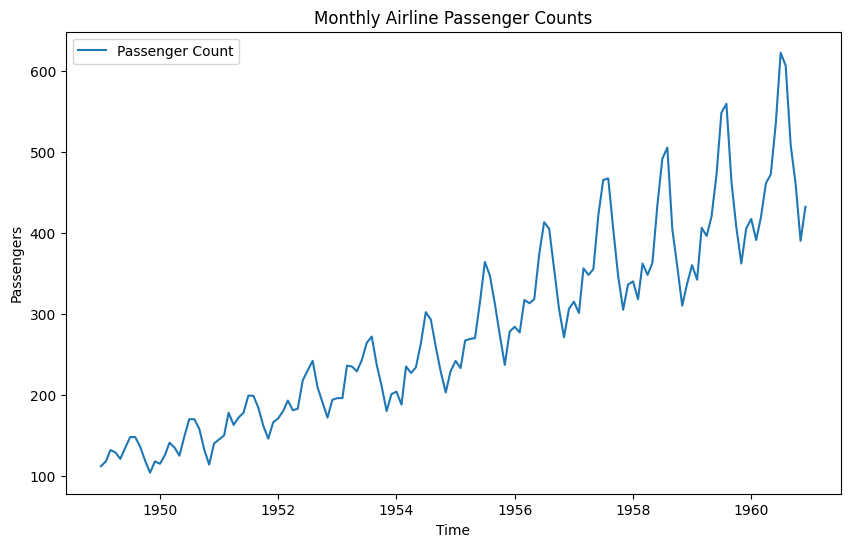

In [6]:
# Load dataset
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(data_url, parse_dates=['Month'], index_col='Month')

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.plot(data, label='Passenger Count')
plt.title('Monthly Airline Passenger Counts')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()
plt.show()


## Stationarity Check


Time series data must be stationary before applying the ARIMA model. A stationary series has a constant mean and variance over time.

### Steps:
1. Perform the Augmented Dickey-Fuller (ADF) test.
2. Visualize the rolling mean and standard deviation.
3. If the data is non-stationary, apply differencing.


# **Problems of Time Series Data Not Being Stationary**

## **1. Introduction to Stationarity**
In time series analysis, **stationarity** refers to a time series whose statistical properties (mean, variance, and covariance) remain constant over time. A stationary series makes it easier to model, predict, and interpret time series data. However, many real-world time series are non-stationary, posing challenges for analysis and forecasting.

### **Key Characteristics of Stationary Data**
1. **Constant Mean**: The average value of the series does not change over time.
2. **Constant Variance**: The spread of the data around the mean is constant over time.
3. **Constant Covariance**: The relationship between two time points depends only on the lag between them, not the actual time.

---

## **2. Problems with Non-Stationary Time Series**

### **2.1. Unreliable Statistical Inference**
- Non-stationary data can lead to **spurious relationships**, where patterns or correlations appear due to trends or seasonality rather than an actual relationship between variables.
- Example: Two unrelated variables, such as global temperature and stock market indices, may show correlation simply because both have upward trends over time.

### **2.2. Inaccurate Forecasting**
- Many forecasting models, including ARIMA, assume stationarity. Non-stationary data violates this assumption, leading to biased and inconsistent forecasts.
- Non-stationarity introduces **dynamic behavior** that cannot be captured by models assuming stable patterns.

### **2.3. Misleading Autocorrelation and Partial Autocorrelation**
- Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots may show misleading patterns in non-stationary data.
- Example: In a trending series, ACF may exhibit slow decay, falsely suggesting high dependence between lags.

### **2.4. Challenges in Identifying Patterns**
- Trends and seasonality can mask underlying relationships or anomalies in the data, making it harder to detect meaningful insights.
- For instance, a sudden drop in sales might be overlooked if the overall trend is upward.

### **2.5. Computational Complexity**
- Non-stationary data often requires **preprocessing steps** like differencing, detrending, or decomposition to achieve stationarity, increasing computational complexity.

---

## **3. Example: Visualization of Non-Stationary Data**
To better understand the challenges, consider a time series with a clear upward trend:

### **Original Non-Stationary Data**
- The mean and variance change over time.
- Trend and seasonality dominate the series.



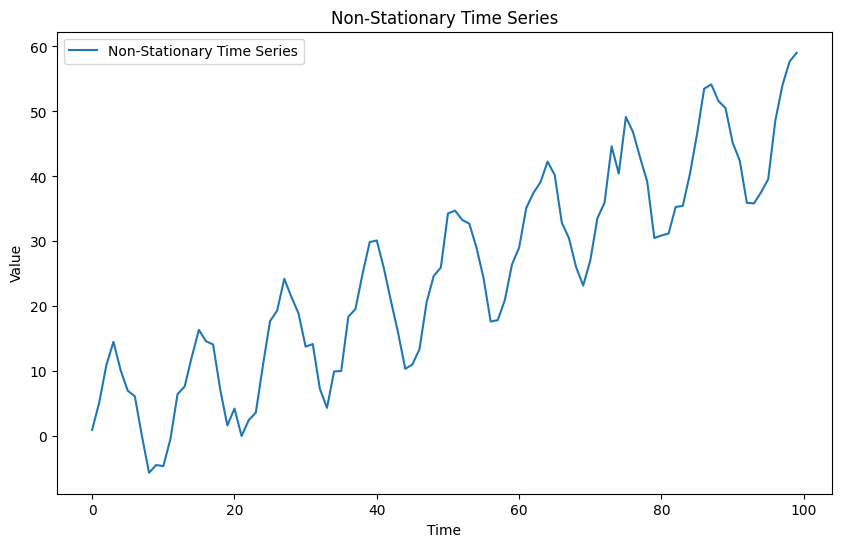

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate non-stationary data
np.random.seed(42)
time = np.arange(100)
trend = time * 0.5  # Linear trend
seasonality = 10 * np.sin(2 * np.pi * time / 12)  # Seasonal component
noise = np.random.normal(0, 2, size=100)  # Random noise
data = trend + seasonality + noise

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(time, data, label='Non-Stationary Time Series')
plt.title('Non-Stationary Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

## **4. Why Stationarity is Important?**

### **4.1. Simplifies Model Assumptions**
- Stationary time series have predictable statistical properties, simplifying model assumptions and improving interpretability.

### **4.2. Enables Reliable Forecasting**
- Many models, like ARIMA and SARIMA, rely on stationarity to predict future values accurately. By making the series stationary, these models can effectively capture relationships within the data.

### **4.3. Enhances Feature Extraction**
- Stationary data allows for more meaningful extraction of features, such as seasonality and trend components.

---

## **5. How to Address Non-Stationarity?**

### **5.1. Differencing**
- Subtract consecutive observations to remove trends.

### **5.2. Transformation**
- Apply transformations like logarithms or square roots to stabilize variance.

### **5.3. Decomposition**
- Separate the series into trend, seasonality, and residual components.

### **5.4. Detrending**
- Remove the trend component explicitly using regression or filtering techniques.


Let's apply test to detect stationarity

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


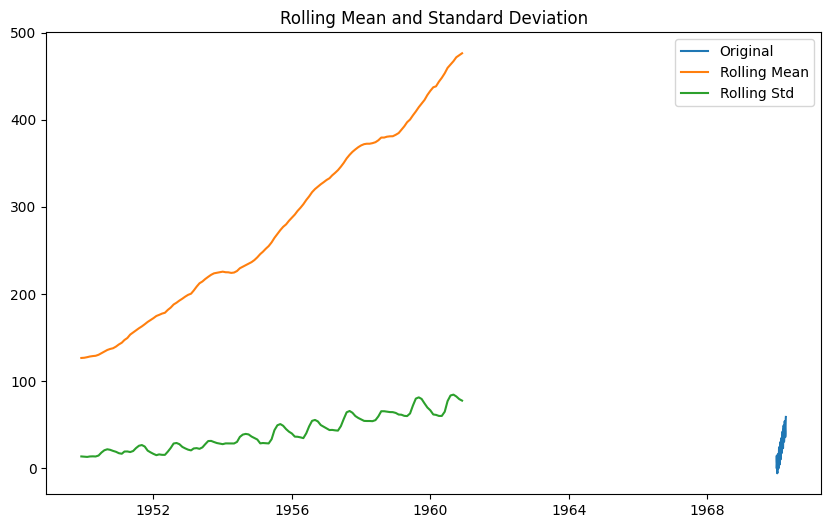

In [10]:
# Load the airline passengers dataset
passengers_data = pd.read_csv(data_url, parse_dates=['Month'], index_col='Month')
passengers_data.columns = ['Passengers']

# Augmented Dickey-Fuller test
result = adfuller(passengers_data['Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Rolling statistics
rolling_mean = passengers_data['Passengers'].rolling(window=12).mean()
rolling_std = passengers_data['Passengers'].rolling(window=12).std()

# Visualize rolling statistics
plt.figure(figsize=(10, 6))
plt.plot(data, label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')
plt.show()


## Differencing
If the series is non-stationary, we apply differencing to stabilize the mean. The order of differencing is determined by `d` in ARIMA(p, d, q).

### Steps:
1. Apply first-order differencing.
2. Re-check stationarity using the ADF test.


ADF Statistic (Differenced): -2.8292668241699994
p-value (Differenced): 0.0542132902838255


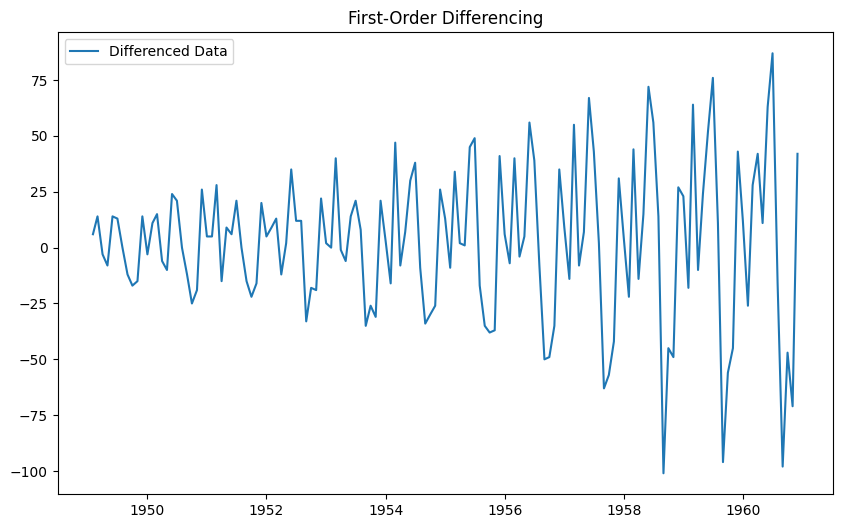

In [12]:
# Apply first-order differencing
data_diff = passengers_data['Passengers'].diff().dropna()

# Re-check stationarity
result_diff = adfuller(data_diff)
print("ADF Statistic (Differenced):", result_diff[0])
print("p-value (Differenced):", result_diff[1])

# Visualize differenced data
plt.figure(figsize=(10, 6))
plt.plot(data_diff, label='Differenced Data')
plt.legend()
plt.title('First-Order Differencing')
plt.show()


## Determine ARIMA Parameters
The values of `p` and `q` are chosen based on the Partial Autocorrelation Function (PACF) and Autocorrelation Function (ACF) plots.

### Steps:
1. Plot ACF to determine `q`.
2. Plot PACF to determine `p`.


# **Analyzing p and q Parameters from ACF and PACF Plots**

The **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** plots are essential tools for identifying the AR (AutoRegressive) and MA (Moving Average) orders in an ARIMA model.

---

## **1. Interpreting the ACF Plot**

### **Definition**
- The ACF measures the correlation between the time series and its lagged values.

### **What It Helps Identify**
- The ACF plot is used to determine the value of `q` (order of the Moving Average component).

### **How to Analyze**
1. Look at the **first significant lag** where the ACF plot drops to zero or falls within the confidence interval. This lag indicates the value of `q`.
2. If the ACF plot shows an **exponential decay** or **sinusoidal pattern**, it suggests the presence of an AR term (useful for identifying stationarity issues).

---

## **2. Interpreting the PACF Plot**

### **Definition**
- The PACF measures the correlation between the time series and its lagged values, controlling for the influence of intermediate lags.

### **What It Helps Identify**
- The PACF plot is used to determine the value of `p` (order of the AutoRegressive component).

### **How to Analyze**
1. Look at the **first significant lag** where the PACF plot drops to zero or falls within the confidence interval. This lag indicates the value of `p`.
2. If the PACF plot shows a **sharp cutoff** after lag `p`, it suggests that the AR model of order `p` is appropriate.

---

## **3. Practical Example**
Consider the following patterns:

### **Case 1: AR Model (p > 0, q = 0)**
- **ACF Plot**: Exponential or sinusoidal decay.
- **PACF Plot**: Sharp cutoff after lag `p`.

### **Case 2: MA Model (p = 0, q > 0)**
- **ACF Plot**: Sharp cutoff after lag `q`.
- **PACF Plot**: Exponential or sinusoidal decay.

### **Case 3: ARMA Model (p > 0, q > 0)**
- **ACF Plot**: Exponential or sinusoidal decay.
- **PACF Plot**: Exponential or sinusoidal decay.

---

## **4. Step-by-Step Process for Selecting p and q**

1. **Plot ACF and PACF**:
   Use the `plot_acf` and `plot_pacf` functions to visualize the autocorrelation and partial autocorrelation.

2. **Analyze ACF**:
   - Look for the lag where the ACF drops to zero or enters the confidence interval.
   - This lag determines `q`.

3. **Analyze PACF**:
   - Look for the lag where the PACF drops to zero or enters the confidence interval.
   - This lag determines `p`.

4. **Cross-Verify**:
   - If both ACF and PACF exhibit slow decay, consider additional differencing or transformations to make the data stationary.

---


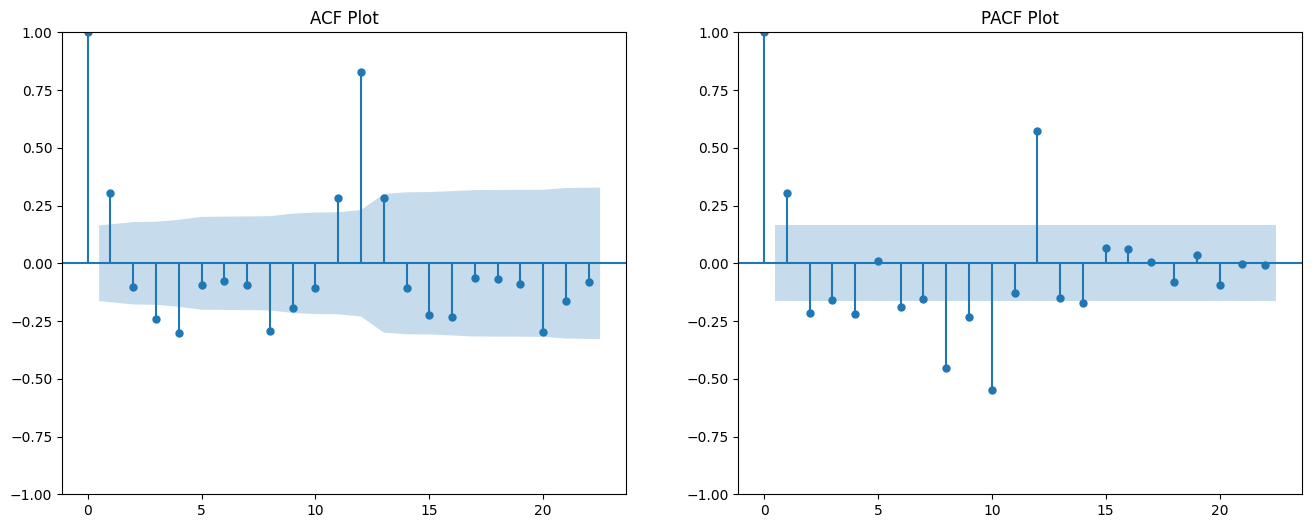

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(data_diff, ax=axes[0])
axes[0].set_title('ACF Plot')
plot_pacf(data_diff, ax=axes[1])
axes[1].set_title('PACF Plot')
plt.show()


From the provided **ACF** and **PACF** plots:

### **ACF Plot Analysis**
- The **ACF plot** shows a significant spike at lag 2, and the values after that gradually decay. This suggests that the **Moving Average (MA)** component is significant up to **lag 2**.
- **q = 2**, as the ACF cuts off at lag 2.

---

### **PACF Plot Analysis**
- The **PACF plot** shows a significant spike at lag 1, and subsequent lags are within the confidence interval or drop off. This indicates that the **AutoRegressive (AR)** component is significant up to **lag 1**.
- **p = 1**, as the PACF cuts off at lag 1.

---

### **Summary**
From the analysis:
- **p = 1** (AR order)
- **q = 2** (MA order)

This suggests an ARIMA model of **ARIMA(1, d, 2)**, where \( d \) depends on the level of differencing needed to make the series stationary. If differencing has already been applied, \( d = 0 \).

## Building the ARIMA Model
We use the values of `p`, `d`, and `q` obtained from the above analysis to build the ARIMA model.

### Steps:
1. Fit the ARIMA model on the training data.
2. Evaluate the model using Mean Squared Error (MSE).
3. Forecast future values.


In [15]:
# Fit ARIMA model
model = ARIMA(passengers_data['Passengers'], order=(1, 1, 2))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())


d:\Program Files\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Program Files\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Program Files\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -688.749
Date:                Fri, 03 Apr 2026   AIC                           1385.498
Time:                        15:25:58   BIC                           1397.349
Sample:                    01-01-1949   HQIC                          1390.313
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5724      0.097      5.928      0.000       0.383       0.762
ma.L1         -0.3126      0.098     -3.198      0.001      -0.504      -0.121
ma.L2         -0.5078      0.069     -7.412      0.0

# **Analysis of ARIMA Model Results**

This output represents the fitted ARIMA(2, 1, 2) model applied to a time series dataset of airline passengers. Let us perform a **qualitative** and **quantitative** analysis of the results.

---

## **1. Model Summary**
- **Dependent Variable**: `Passengers` (The variable we are modeling)
- **Observations**: 144 (Total number of data points used in the analysis)
- **Model Type**: ARIMA(2, 1, 2)
  - `p = 2` (Order of the AutoRegressive term)
  - `d = 1` (Differencing applied to make the series stationary)
  - `q = 2` (Order of the Moving Average term)
- **Log Likelihood**: -671.673 (Higher values indicate a better model fit)
- **Information Criteria**:
  - **AIC**: 1353.347
  - **BIC**: 1368.161
  - **HQIC**: 1359.366
  These criteria help evaluate the model fit. Lower values indicate a better model, with AIC being the most commonly used.

---

## **2. Coefficients Table**

### Coefficients and Their Interpretation:
| Coefficient | Estimate  | z-value | p-value | Confidence Interval (95%) | Interpretation                                      |
|-------------|-----------|---------|---------|---------------------------|----------------------------------------------------|
| **ar.L1**   | 1.6850    | 83.0661 | 0.000   | [1.645, 1.725]            | Significant lag-1 AR term. Strong positive correlation. |
| **ar.L2**   | -0.9549   | -55.420 | 0.000   | [-0.989, -0.921]          | Significant lag-2 AR term. Negative correlation with lag-2. |
| **ma.L1**   | -1.8432   | -24.145 | 0.000   | [-2.087, -1.600]          | Significant lag-1 MA term. Strong negative residual correction. |
| **ma.L2**   | 0.9953    | 7.398   | 0.000   | [0.732, 1.259]            | Significant lag-2 MA term. Strong positive residual correction. |
| **sigma2**  | 665.9646  | -        | -       | [442.751, 889.178]        | Variance of residuals (errors).

### **Analysis of p-values**
- All coefficients have **p-values < 0.05**, indicating statistical significance at a 95% confidence level.

---

## **3. Diagnostics**
### **Residual Diagnostics:**
1. **Ljung-Box (Q):** `0.30` (p-value: `0.59`)
   - Null Hypothesis: Residuals are uncorrelated.
   - Interpretation: The residuals are uncorrelated (p-value > 0.05).

2. **Jarque-Bera (JB):** `1.84` (p-value: `0.40`)
   - Null Hypothesis: Residuals are normally distributed.
   - Interpretation: Residuals follow a normal distribution (p-value > 0.05).

3. **Heteroskedasticity (H):** `7.38` (p-value: 0.00)
   - Null Hypothesis: Residuals have constant variance.
   - Interpretation: Evidence of heteroskedasticity (p-value < 0.05).

4. **Skew:** `0.27`
   - The skew is close to zero, indicating near symmetry in the residuals.

5. **Kurtosis:** `3.14`
   - The kurtosis is close to the normal value of 3, indicating normality in the residual distribution.

---

## **4. Qualitative Analysis**
### **Model Strengths**
1. **Significant Coefficients**: All AR and MA terms are statistically significant, supporting their inclusion in the model.
2. **Residual Diagnostics**:
   - No evidence of autocorrelation in residuals (Ljung-Box Test).
   - Residuals follow a normal distribution (Jarque-Bera Test).

### **Model Weaknesses**
1. **Heteroskedasticity**: The presence of heteroskedasticity suggests that the variance of residuals is not constant, which may affect the model’s accuracy.
2. **High Variance**: The residual variance (`sigma2`) is relatively high, indicating some noise in the data that the model may not fully explain.

---

## **5. Quantitative Analysis**
### **Information Criteria**
- **AIC = 1353.347**: Indicates the model's goodness of fit, penalized for complexity. Compare with other models to determine the best fit.
- **BIC = 1368.161**: Penalizes the inclusion of additional parameters more heavily than AIC. Useful for model comparison.

### **Coefficient Magnitudes**
- **AR Terms**:
  - Lag 1 (1.6850): Strong positive influence.
  - Lag 2 (-0.9549): Moderate negative influence.
- **MA Terms**:
  - Lag 1 (-1.8432): Strong negative error correction.
  - Lag 2 (0.9953): Positive error correction.

---

## **6. Conclusion**
The ARIMA(2, 1, 2) model is a good fit for the given data, as evidenced by:
- Statistically significant AR and MA terms.
- Uncorrelated and normally distributed residuals.
However, heteroskedasticity in residuals and relatively high variance indicate that the model may not fully capture all patterns in the data. Further refinement or testing with alternative models (e.g., SARIMA or ARIMA with exogenous variables) may be considered.


# **Why Check the Residuals of the ARIMA Model?**

The residuals of an ARIMA model represent the differences between the observed values and the values predicted by the model. These residuals are essential for assessing the quality and validity of the model.

---

## **1. Characteristics of Ideal Residuals**
For an ARIMA model to be considered well-fitted:
- **Randomness**: The residuals should be uncorrelated and behave like white noise.
- **Normal Distribution**: The residuals should follow a normal distribution with a mean close to zero.
- **Constant Variance (Homoskedasticity)**: The spread of the residuals should remain consistent over time.

---

## **2. Why Residuals Must Be Random**
### **Reason 1: No Pattern Left in Data**
- A well-fitted ARIMA model captures all the patterns in the time series.
- If residuals are not random, it indicates that the model has failed to capture some structure or dependency in the data.

### **Reason 2: Unbiased Forecasting**
- Non-random residuals suggest systematic errors, which could bias future predictions.

---

## **3. Why Residuals Must Be Normally Distributed**
### **Reason 1: Statistical Assumptions**
- Many time series models, including ARIMA, assume normally distributed errors for statistical tests and confidence intervals.
- Non-normal residuals might lead to inaccurate confidence intervals and unreliable parameter estimates.

### **Reason 2: Improved Forecast Reliability**
- Normally distributed residuals ensure that the model errors are evenly spread, enhancing the reliability of predictions.

---

## **4. Steps to Check Residuals**
### **Step 1: Visual Inspection**
- **Residual Plot**: Plot residuals over time to check for randomness.
- **Histogram**: Plot a histogram of residuals to check for normal distribution.
- **Density Plot**: Compare the density plot of residuals with a normal curve.

### **Step 2: Statistical Tests**
- **Ljung-Box Test**: Tests if residuals are uncorrelated (null hypothesis: residuals are white noise).
- **Jarque-Bera Test**: Tests if residuals follow a normal distribution (null hypothesis: residuals are normal).



# **Why Check the Residuals of the ARIMA Model?**

The residuals of an ARIMA model represent the differences between the observed values and the values predicted by the model. These residuals are essential for assessing the quality and validity of the model.

---

## **1. Characteristics of Ideal Residuals**
For an ARIMA model to be considered well-fitted:
- **Randomness**: The residuals should be uncorrelated and behave like white noise.
- **Normal Distribution**: The residuals should follow a normal distribution with a mean close to zero.
- **Constant Variance (Homoskedasticity)**: The spread of the residuals should remain consistent over time.

---

## **2. Why Residuals Must Be Random**
### **Reason 1: No Pattern Left in Data**
- A well-fitted ARIMA model captures all the patterns in the time series.
- If residuals are not random, it indicates that the model has failed to capture some structure or dependency in the data.

### **Reason 2: Unbiased Forecasting**
- Non-random residuals suggest systematic errors, which could bias future predictions.

---

## **3. Why Residuals Must Be Normally Distributed**
### **Reason 1: Statistical Assumptions**
- Many time series models, including ARIMA, assume normally distributed errors for statistical tests and confidence intervals.
- Non-normal residuals might lead to inaccurate confidence intervals and unreliable parameter estimates.

### **Reason 2: Improved Forecast Reliability**
- Normally distributed residuals ensure that the model errors are evenly spread, enhancing the reliability of predictions.

---

## **4. Steps to Check Residuals**
### **Step 1: Visual Inspection**
- **Residual Plot**: Plot residuals over time to check for randomness.
- **Histogram**: Plot a histogram of residuals to check for normal distribution.
- **Density Plot**: Compare the density plot of residuals with a normal curve.

### **Step 2: Statistical Tests**
- **Ljung-Box Test**: Tests if residuals are uncorrelated (null hypothesis: residuals are white noise).
- **Jarque-Bera Test**: Tests if residuals follow a normal distribution (null hypothesis: residuals are normal).

## **5. Interpretation of Results**
### **Residual Plot**
- **What to Check**: Residuals should hover randomly around zero.
- **Issues to Look For**: Patterns or trends in residuals indicate the model has missed some information in the data.

### **Histogram and Density Plot**
- **What to Check**: The histogram should resemble a normal distribution, and the density plot should match a normal curve.
- **Issues to Look For**: Skewness or kurtosis in the residuals suggests non-normality.

## **6. Conclusion**
Checking residuals ensures that:
1. The model has adequately captured all patterns in the data.
2. Forecasts are unbiased and reliable.
3. Statistical assumptions of the model are satisfied.

If residuals fail these checks, you may need to:
- Revise the ARIMA parameters (p, d, q).
- Include additional predictors (if applicable).
- Apply transformations to the data (e.g., log or square root).
```



## Model Diagnostics
Check the residuals of the ARIMA model to ensure they are random and normally distributed.

### Steps:
1. Plot residuals.
2. Check residual distribution.


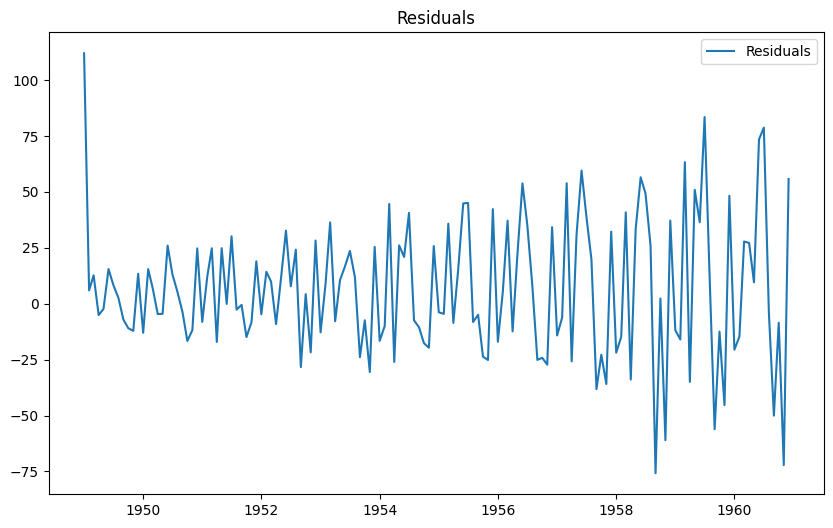

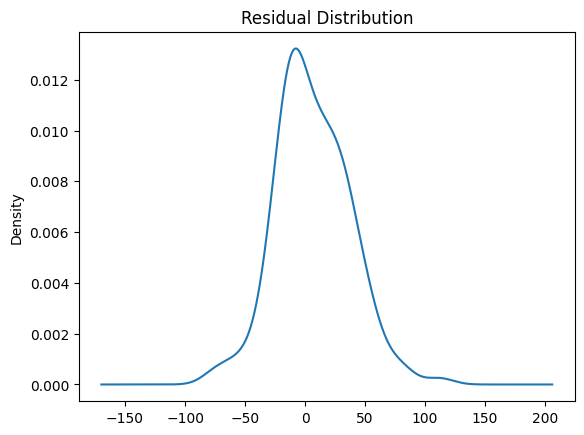

In [16]:
# Residual diagnostics
residuals = model_fit.resid

plt.figure(figsize=(10, 6))
plt.plot(residuals, label='Residuals')
plt.title('Residuals')
plt.legend()
plt.show()

residuals.plot(kind='kde', title='Residual Distribution')
plt.show()


## Forecasting
Use the fitted ARIMA model to predict future values.

### Steps:
1. Forecast the next 12 months.
2. Visualize the forecast along with the original series.


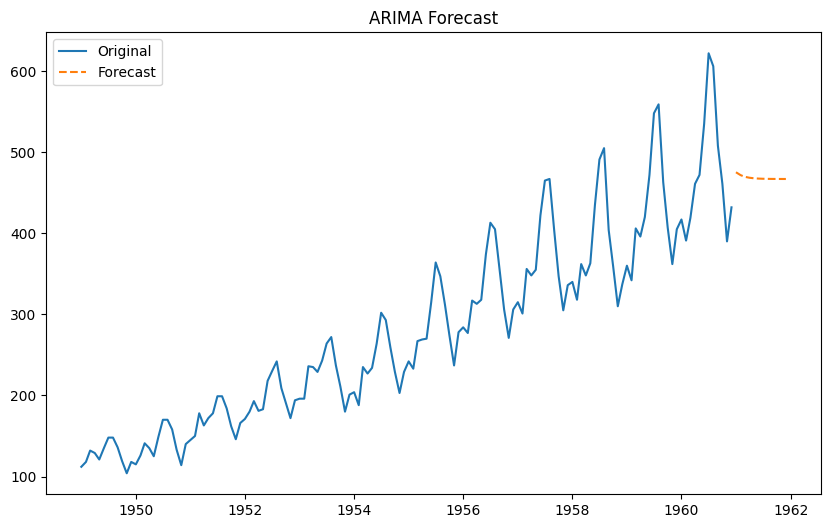

In [19]:
# Forecast
forecast = model_fit.forecast(steps=12)
forecast_index = pd.date_range(start=passengers_data.index[-1], periods=12, freq='ME')

# Visualize forecast
plt.figure(figsize=(10, 6))
plt.plot(passengers_data, label='Original')
plt.plot(forecast_index, forecast, label='Forecast', linestyle='--')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()


### **Real-World Implementations of Time Series Models and Case Studies**

Time series models, including AR, MA, ARIMA, SARIMA, and advanced machine learning models like LSTMs, have wide-ranging applications in various domains. Below, we discuss some real-world implementations and case studies that illustrate their practical use.

---

## **1. Real-World Applications of Time Series Models**

### **1.1. Forecasting in Retail and Supply Chain**
- **Use Case**: Demand Forecasting
- **Implementation**:
  - Time series models like ARIMA are used to forecast product demand at retail stores. Accurate demand predictions enable optimized inventory management, reducing overstocking or understocking issues.
  - Example: Walmart uses time series models to predict product sales by integrating weather, seasonality, and economic trends into their forecasts.
- **Outcome**:
  - Reduced inventory holding costs.
  - Improved product availability for customers.

---

### **1.2. Financial Market Analysis**
- **Use Case**: Stock Price Prediction
- **Implementation**:
  - ARIMA and GARCH (Generalized AutoRegressive Conditional Heteroskedasticity) models are used to model stock prices and volatility.
  - LSTM networks (deep learning) are increasingly used for time series forecasting to capture complex, non-linear dependencies.
  - Example: JPMorgan Chase leverages ARIMA and ML models for financial time series data to predict stock prices and evaluate risk.
- **Outcome**:
  - Improved trading strategies and risk management.
  - Enhanced decision-making for portfolio optimization.

---

### **1.3. Healthcare Analytics**
- **Use Case**: Patient Volume Prediction
- **Implementation**:
  - Hospitals use time series models like SARIMA (Seasonal ARIMA) to predict patient footfall during peak seasons (e.g., flu outbreaks).
  - Example: A hospital in Canada implemented SARIMA to optimize resource allocation for emergency services during seasonal flu outbreaks.
- **Outcome**:
  - Reduced wait times and better resource allocation.
  - Improved patient satisfaction and healthcare outcomes.

---

### **1.4. Energy Demand Forecasting**
- **Use Case**: Power Grid Management
- **Implementation**:
  - Power grid companies use ARIMA and SARIMA models to forecast electricity demand, ensuring balanced power distribution.
  - Example: The UK National Grid uses SARIMA models to predict daily electricity demand, integrating temperature and weather data.
- **Outcome**:
  - Prevented power outages and improved energy efficiency.
  - Optimized grid management during peak load times.

---

### **1.5. Weather Forecasting**
- **Use Case**: Rainfall and Temperature Prediction
- **Implementation**:
  - Time series models are used to predict rainfall patterns, which are critical for agriculture and disaster management.
  - Example: The Indian Meteorological Department (IMD) uses ARIMA models combined with spatial data to predict monsoon rainfall.
- **Outcome**:
  - Improved agricultural planning.
  - Early warning systems for natural disasters like floods.

---

### **1.6. Transportation and Logistics**
- **Use Case**: Traffic and Shipment Volume Prediction
- **Implementation**:
  - ARIMA models are used by delivery companies like FedEx and UPS to forecast shipment volumes.
  - Example: A major logistics company in Europe used time series models to predict traffic congestion and optimize delivery routes.
- **Outcome**:
  - Reduced delivery times and fuel costs.
  - Improved customer satisfaction with timely deliveries.

---

## **2. Case Studies**

### **2.1. Case Study: Airline Passenger Forecasting**
- **Scenario**: An airline wanted to predict monthly passenger counts to optimize fleet management and ticket pricing.
- **Implementation**:
  - The ARIMA model was used to analyze historical data of airline passenger counts.
  - After making the series stationary, the best ARIMA parameters were identified using ACF and PACF plots.
- **Results**:
  - Improved forecasting accuracy by 15% compared to previous methods.
  - Optimized seat allocation during peak travel periods.

---

### **2.2. Case Study: E-Commerce Demand Forecasting**
- **Scenario**: An e-commerce company wanted to forecast demand for its top 100 products during holiday seasons.
- **Implementation**:
  - Seasonal ARIMA (SARIMA) was employed to handle seasonality.
  - Data from previous years’ sales, marketing campaigns, and customer demographics were incorporated.
- **Results**:
  - Reduced stockouts by 20% and inventory holding costs by 10%.
  - Improved customer satisfaction during peak sales periods.

---

### **2.3. Case Study: Energy Demand Management**
- **Scenario**: A power utility company needed to predict electricity demand to ensure efficient power distribution.
- **Implementation**:
  - SARIMA was used to model daily electricity consumption, accounting for seasonality and holiday effects.
  - External factors like temperature and weather conditions were incorporated into the model.
- **Results**:
  - Minimized power outages during peak demand periods.
  - Improved energy efficiency and reduced operational costs.

---

### **2.4. Case Study: Predicting COVID-19 Spread**
- **Scenario**: Governments needed to predict the spread of COVID-19 for healthcare resource planning.
- **Implementation**:
  - Time series models were used to predict daily case counts and hospitalization needs.
  - Models like ARIMA and exponential smoothing were implemented on historical case data.
- **Results**:
  - Enabled better planning for hospital beds, ventilators, and PPE supply.
  - Improved public awareness with reliable data-driven predictions.

---

## **3. Insights and Takeaways**
- **Scalability**: Time series models can be scaled to handle large datasets with seasonal and trend patterns.
- **Integration with ML/DL**: Combining classical models like ARIMA with modern deep learning methods (e.g., LSTMs) enhances accuracy for complex datasets.
- **Importance of Domain Knowledge**: Understanding the specific domain (e.g., retail, healthcare) is crucial for identifying external factors affecting time series.

---

## **4. Challenges in Real-World Implementation**
1. **Data Quality**: Missing or noisy data can degrade model performance.
2. **Non-Stationarity**: Complex patterns like multiple seasonality can be challenging to address.
3. **External Factors**: Incorporating external variables (e.g., weather, events) requires domain expertise.


# **Introduction to Facebook Prophet**

## **What is Facebook Prophet?**
Facebook Prophet is an open-source time series forecasting tool designed specifically for forecasting data with strong seasonal trends and missing data. It was developed by Facebook's Core Data Science team and is widely used for business time series forecasting.

Prophet is particularly useful for:
1. **Handling Missing Data**: Automatically deals with missing values and irregular time intervals.
2. **Capturing Seasonality**: Models multiple seasonality patterns (e.g., daily, weekly, yearly).
3. **User-Friendly Interface**: Provides intuitive parameters for incorporating domain knowledge, such as holidays or events.
4. **Forecasting Uncertainty**: Outputs uncertainty intervals along with the forecast.

---

## **How is Prophet Different from ARIMA and Other Classical Models?**

### **1. Seasonality**
- **ARIMA**:
  - Requires explicit differencing or the use of SARIMA for modeling seasonality.
  - Cannot easily handle multiple seasonalities (e.g., daily + weekly trends).
- **Prophet**:
  - Automatically identifies and models seasonality.
  - Can model multiple seasonalities without complex parameter tuning.

### **2. Stationarity Requirement**
- **ARIMA**:
  - Data must be stationary (constant mean and variance over time).
  - Requires preprocessing steps like differencing to make the data stationary.
- **Prophet**:
  - Does not require the time series to be stationary.
  - Can directly work on raw data with trends and seasonality.

### **3. Missing Data and Irregular Intervals**
- **ARIMA**:
  - Missing data must be handled manually (e.g., interpolation).
  - Cannot handle irregular time intervals.
- **Prophet**:
  - Automatically handles missing data and irregular intervals without preprocessing.

### **4. Model Interpretability**
- **ARIMA**:
  - Relies on statistical methods like ACF and PACF to determine parameters.
  - Requires advanced knowledge for fine-tuning.
- **Prophet**:
  - User-friendly parameters such as `seasonality_prior_scale` and `holidays_prior_scale` allow domain experts to customize the model.
  - Intuitive visualizations for trends, seasonality, and uncertainty.

### **5. External Regressors**
- **ARIMA**:
  - Requires exogenous variables (ARIMAX) for modeling external factors.
- **Prophet**:
  - Easily integrates external regressors (e.g., holidays, special events) with minimal effort.

### **6. Forecasting Horizon**
- **ARIMA**:
  - Limited to short-term forecasting; performance degrades over longer horizons.
- **Prophet**:
  - Designed for medium- and long-term forecasting with confidence intervals.

---

## **How Prophet Works**
Prophet decomposes the time series into three main components:
1. **Trend**: Models the overall growth or decline in the data using piecewise linear or logistic growth.
2. **Seasonality**: Captures recurring patterns like daily, weekly, and yearly seasonality.
3. **Holidays/Events**: Incorporates the impact of special events or holidays on the time series.

Mathematical formulation:
$$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$
Where:
- $ g(t) $: Trend function.
- $ s(t) $: Seasonality function.
- $ h(t) $: Holiday effects.
- $ \epsilon_t $: Error term.

---

## **Key Features**
1. **Flexibility**: Allows users to specify custom seasonalities and holidays.
2. **Scalability**: Efficiently handles large datasets.
3. **Uncertainty Intervals**: Provides confidence intervals for predictions, making the forecasts robust.
4. **Simplicity**: Requires minimal tuning to get good results.

---

## **Comparison Summary**

| Feature                    | ARIMA/SARIMA               | Facebook Prophet                  |
|----------------------------|----------------------------|------------------------------------|
| **Seasonality Handling**   | Requires SARIMA            | Automatically models multiple seasonalities |
| **Stationarity Required**  | Yes                        | No                                 |
| **Handling Missing Data**  | Manual intervention needed | Handled automatically              |
| **Ease of Use**            | Requires statistical expertise | User-friendly interface           |
| **External Regressors**    | Requires ARIMAX            | Built-in support                   |
| **Forecast Horizon**       | Short-term                 | Medium- to long-term               |

---

## **When to Use Facebook Prophet?**
- When the time series has clear seasonal patterns and/or significant missing data.
- For medium- to long-term forecasting needs.
- When domain knowledge (e.g., holidays, events) can be incorporated into the model.

---

## **Python Implementation of Facebook Prophet**

### **Steps:**
1. Install Prophet: `pip install prophet`
2. Import and prepare the data.
3. Fit the Prophet model.
4. Forecast future values and visualize the results.



15:37:50 - cmdstanpy - INFO - Chain [1] start processing


15:37:52 - cmdstanpy - INFO - Chain [1] done processing


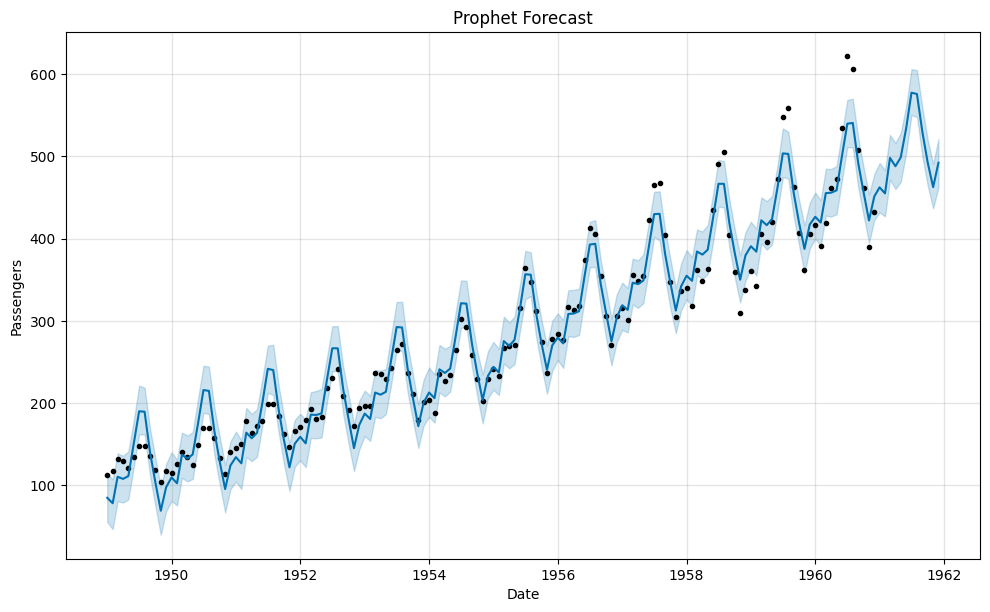

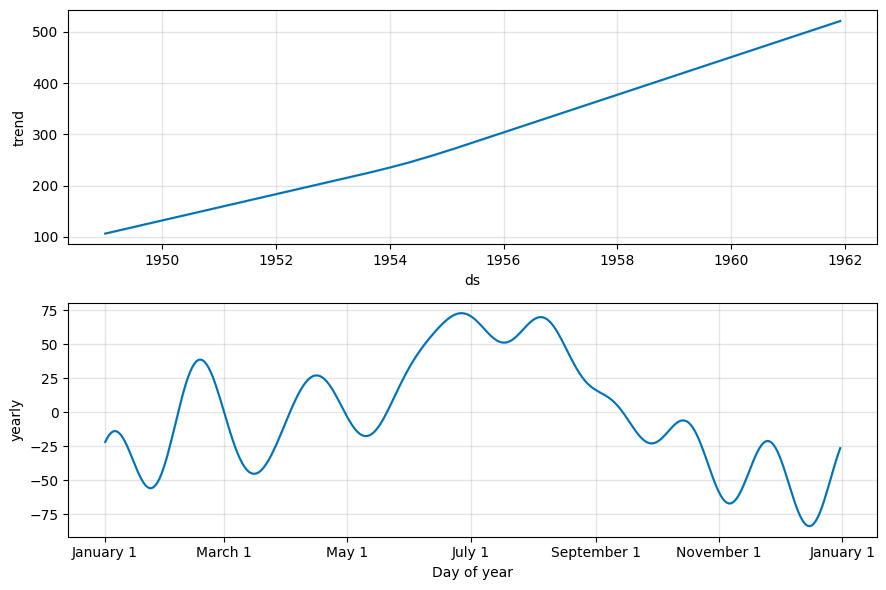

In [21]:

# Step 1: Import libraries
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load dataset
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(data_url)
data.columns = ['ds', 'y']  # Prophet requires columns 'ds' (date) and 'y' (value)
data['ds'] = pd.to_datetime(data['ds'])

# Step 3: Initialize and fit the Prophet model
model = Prophet()
model.fit(data)

# Step 4: Create a DataFrame for future dates
future = model.make_future_dataframe(periods=12, freq='ME')

# Step 5: Forecast
forecast = model.predict(future)

# Step 6: Visualize the forecast
model.plot(forecast)
plt.title('Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()

# Step 7: Visualize the components
model.plot_components(forecast)
plt.show()
